In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [4]:
df= pd.read_csv("insurance.csv")

## EDA

In [5]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.shape

(1338, 7)

In [7]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [12]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

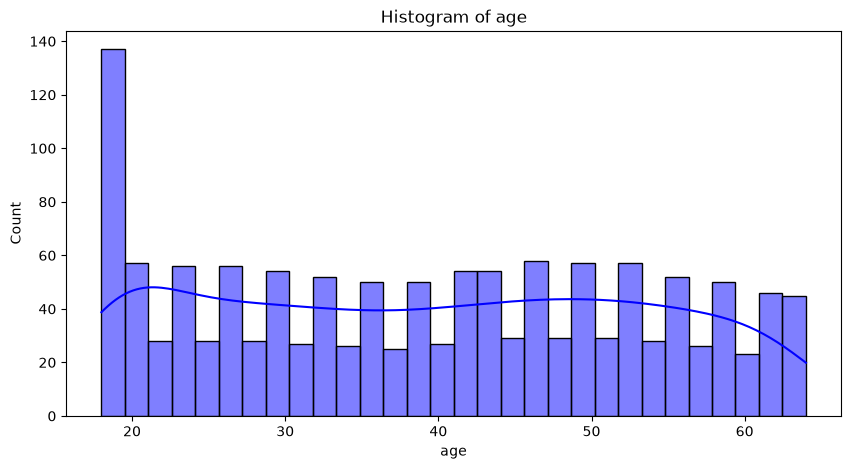

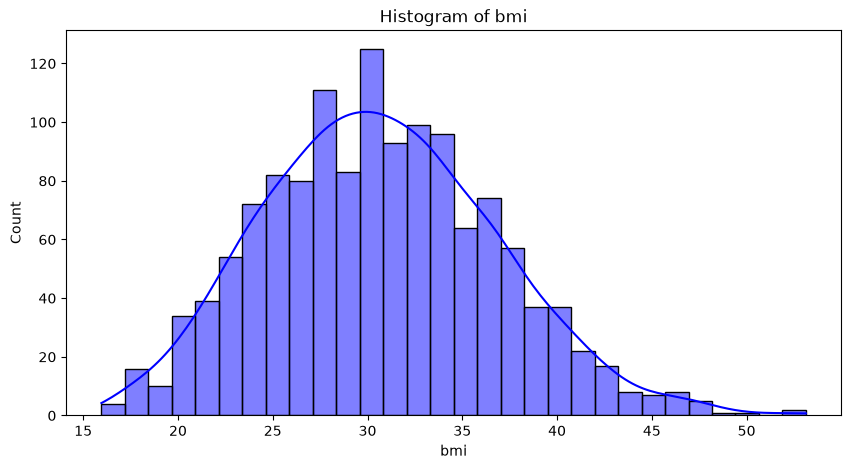

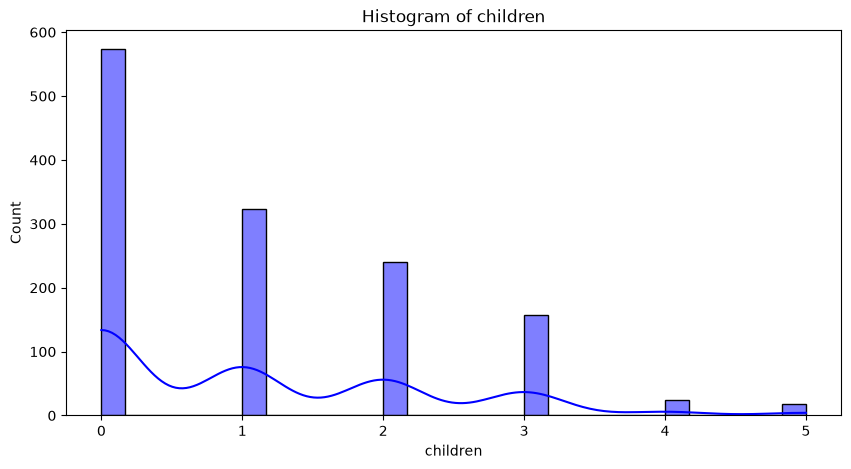

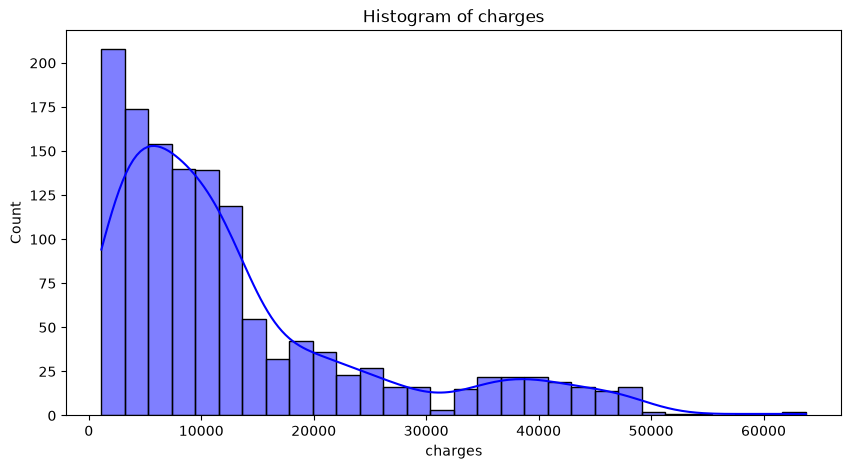

In [13]:
numeric_columns=['age', 'bmi', 'children',  'charges']
for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df[col], kde=True, color='blue', bins=30)
    plt.title(f'Histogram of {col}')
    plt.show()

<Axes: xlabel='children', ylabel='count'>

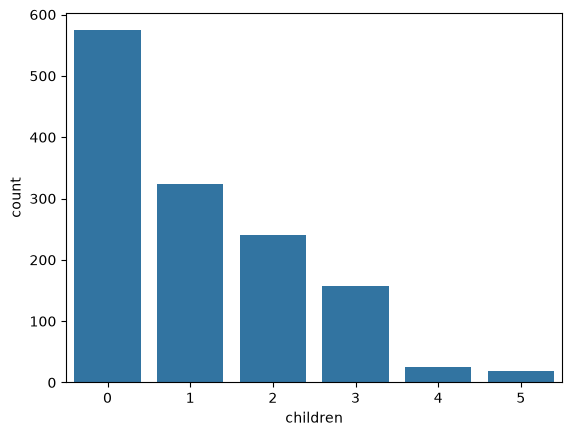

In [14]:
sns.countplot(x='children', data=df)

<Axes: xlabel='sex', ylabel='count'>

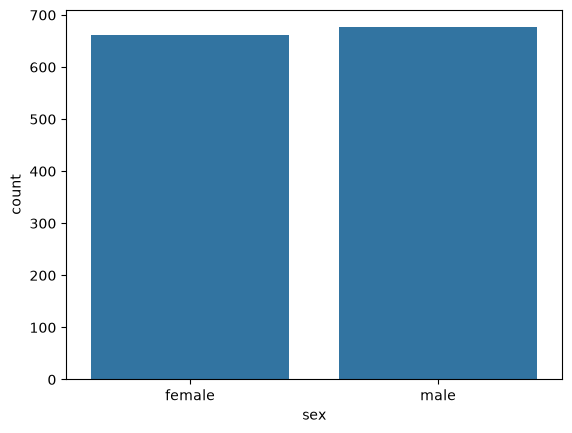

In [15]:
sns.countplot(x='sex', data=df) 

<Axes: xlabel='smoker', ylabel='count'>

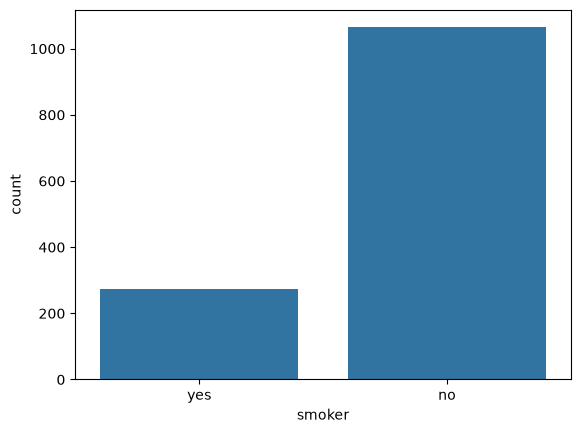

In [16]:
sns.countplot(x='smoker', data=df)

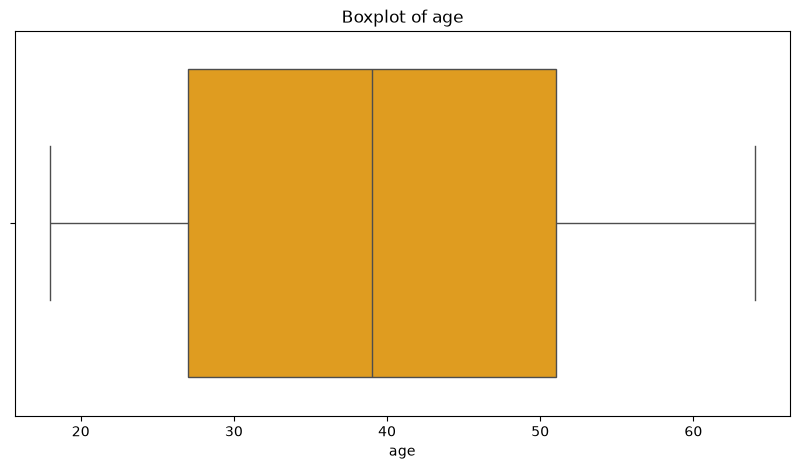

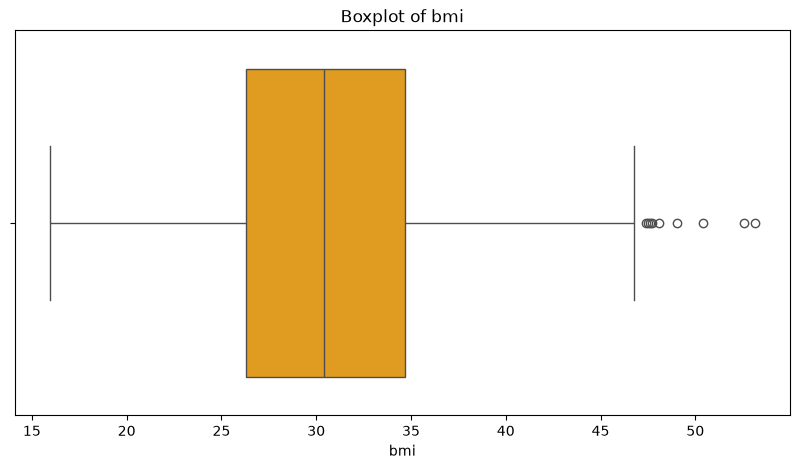

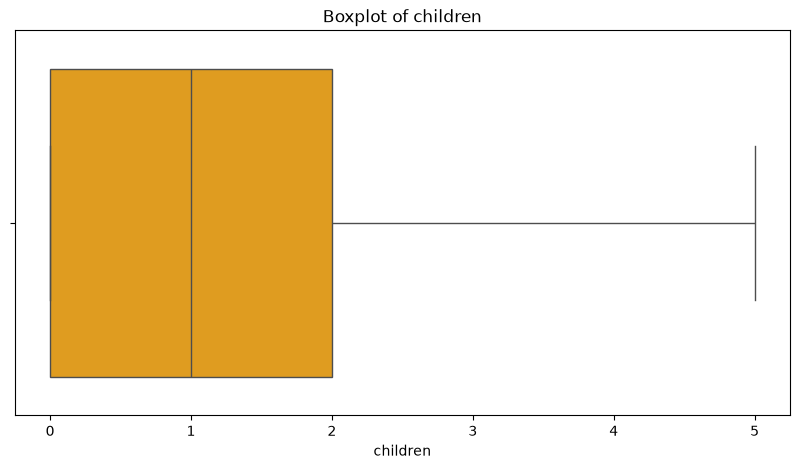

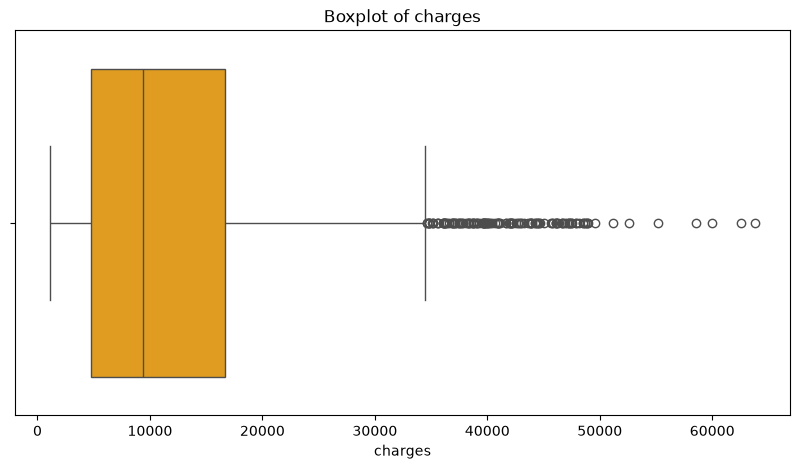

In [17]:
for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.show()

<Axes: >

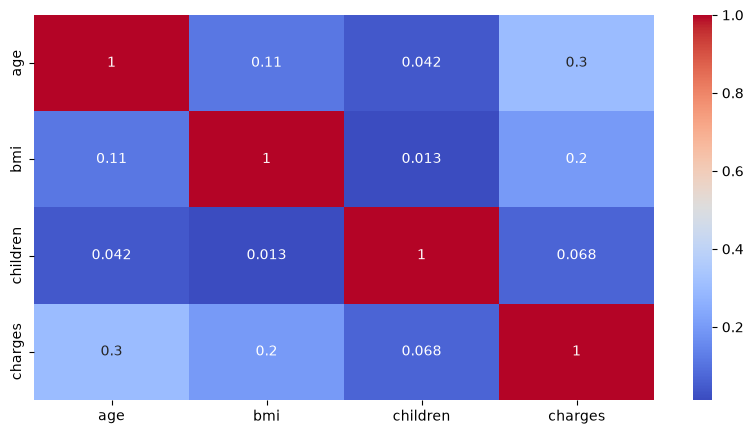

In [18]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

## DATA CLEANING & PREPROCESSING

In [19]:
df_cleaned=df.copy()

In [20]:
df_cleaned.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
df_cleaned.drop_duplicates(inplace=True)

In [22]:
df_cleaned.shape

(1337, 7)

In [23]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [24]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [25]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [26]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0, 'female':1}) 

In [27]:
df_cleaned.head(5)


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [28]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1, 'no':0}) 

In [29]:
df_cleaned.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [30]:
df_cleaned.rename(columns={'sex':'is_female', 'smoker':'is_smoker'}, inplace=True)

In [31]:
df_cleaned.head(5)

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [32]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [33]:
df_cleaned=pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [34]:
df_cleaned.head(5)   

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [35]:
df_cleaned=df_cleaned.astype(int)

In [36]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


## Feature Engineering & Extraction

<Axes: xlabel='bmi', ylabel='Count'>

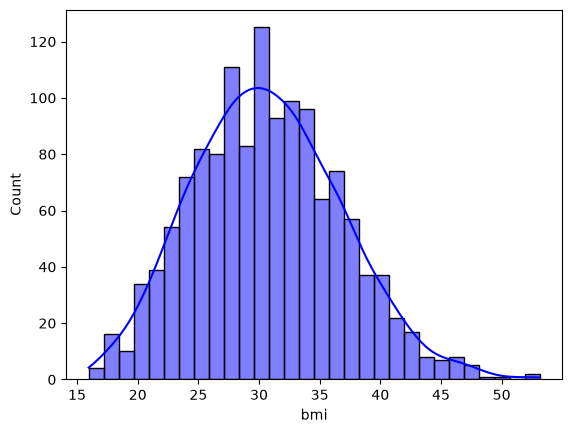

In [37]:
sns.histplot(df['bmi'], kde=True, color='blue', bins=30)

In [38]:
df_cleaned['bmi_category']= pd.cut(df_cleaned['bmi'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['Underweight', 'Normal weight', 'Overweight', 'Obesity'])     

In [39]:
df_cleaned.head(5)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obesity
2,28,0,33,3,0,4449,0,1,0,Obesity
3,33,0,22,0,0,21984,1,0,0,Normal weight
4,32,0,28,0,0,3866,1,0,0,Overweight


In [40]:
df_cleaned=pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)  

In [41]:
df_cleaned=df_cleaned.astype(int)

In [42]:
df_cleaned.head(5)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [43]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obesity'],
      dtype='str')

In [44]:
from sklearn.preprocessing import StandardScaler
cols=['age', 'bmi', 'children']
scaler=StandardScaler()

df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [45]:
df_cleaned.head(5)


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [46]:
from scipy.stats import pearsonr


selected_features=['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest','bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obesity']


correlations={
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0] for feature in selected_features
}


correlations_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlations_df.sort_values(by='Pearson Correlation', ascending=False, inplace=True)

In [47]:
correlations_df

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obesity,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_Normal weight,-0.104042


In [48]:
cat_features=['is_female', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obesity']

In [49]:
from scipy.stats import chi2_contingency
import pandas as pd 

alpha = 0.05

df_cleaned['charges_bin']=pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency_table)
    decision='Reject null (keep Feature)' if p_val< alpha else 'Fail to reject null (drop Feature)'
    chi2_results[col] = {'chi2_statistic': chi2_stat, 'p_value': p_val, 'decision': decision}
    chi2_df = pd.DataFrame(chi2_results).T
    chi2_df =chi2_df.sort_values(by='p_value', ascending=True)
    chi2_df

In [50]:
chi2_df

,chi2_statistic,p_value,decision
is_smoker,848.219178,0.0,Reject null (keep Feature)
region_southeast,15.998167,0.001135,Reject null (keep Feature)
is_female,10.258784,0.01649,Reject null (keep Feature)
bmi_category_Obesity,8.515711,0.036473,Reject null (keep Feature)
region_southwest,5.091893,0.165191,Fail to reject null (drop Feature)
bmi_category_Overweight,4.25149,0.235557,Fail to reject null (drop Feature)
bmi_category_Normal weight,3.708088,0.29476,Fail to reject null (drop Feature)
region_northwest,1.13424,0.768815,Fail to reject null (drop Feature)


In [51]:
final_df=df_cleaned[['age', 'bmi', 'children', 'is_female', 'is_smoker','charges','bmi_category_Obesity','region_southeast', 'region_southwest', 'region_northwest']]

In [52]:
final_df

,age,bmi,children,is_female,is_smoker,charges,bmi_category_Obesity,region_southeast,region_southwest,region_northwest
0,-1.440418,-0.517949,-0.909234,1,1,16884,0,0,1,0
1,-1.511647,0.462463,-0.079442,0,0,1725,1,1,0,0
2,-0.799350,0.462463,1.580143,0,0,4449,1,1,0,0
3,-0.443201,-1.334960,-0.909234,0,0,21984,0,0,0,1
4,-0.514431,-0.354547,-0.909234,0,0,3866,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,10600,1,0,0,1
1334,-1.511647,0.135659,-0.909234,1,0,2205,1,0,0,0
1335,-1.511647,0.952670,-0.909234,1,0,1629,1,1,0,0
1336,-1.297958,-0.844753,-0.909234,1,0,2007,0,0,1,0


In [53]:
from sklearn.model_selection import train_test_split

In [54]:
x=final_df.drop('charges', axis=1) #INPUT FEATURES KO ALAG KR LIYA CHARGERS HATA KE
y=final_df['charges'] #OUTPUT KO ALAG KAAR LIYA

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42) #X_TEST KO Y TEST SE COMPARE KAREGE XTEST HUMARI PREDICTION HOGI AND Y TRAIN ACTUAL CHARGES JO THE VO HOGA

In [56]:
from sklearn.linear_model import LinearRegression 

In [57]:
MODEL=LinearRegression() 
MODEL.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[3486.96, 582.94, 644.27,...,-672.42,-743.38,-424.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['age','bmi','children',...,'region_southeast','region_southwest', 'region_northwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7156
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [58]:
Y_PREDICTED=MODEL.predict(x_test)

In [59]:
Y_PREDICTED

array([ 8220.39408155,  5016.30656048, 14618.98364817, 32440.61836405,
        8976.85820956, 13352.35449636, 30616.60572254,  1043.98863047,
       11219.58156776,  9971.2558439 , 10763.74268416, 32079.53746357,
       31949.01290148, 15942.04920088, 10725.37519233,  8124.2554057 ,
        5162.88914446, 32460.60040385,  2928.85807186,  3864.45755729,
        4781.83751373, 29159.89384863, 13911.2217112 , 29161.63522598,
       31511.38954191,  6347.36001675, 35044.32741425, 37530.26621944,
       12905.98140483, 14655.11127401,  7995.87552987, 13066.11994278,
         478.2106268 , 10971.64196608, 37622.38900062, 13040.36508925,
        3352.92880919,  4477.43670621, 31413.20385813,  7991.57880953,
        6522.53490204, 30753.68953326, 35268.44482214, 13510.64460701,
        7916.82767113,  2629.49317328,  5624.28909918,  7270.7456216 ,
        3482.99347322, 10392.33247363,  7838.05696658, 10948.07795814,
       30695.35162216,  4699.24197594, 11352.25816393, 11443.69897565,
      

In [60]:
y_test

900      8688
1064     5708
1256    11436
298     38746
237      4463
        ...  
534     13831
542     13887
760      3925
1284    47403
1285     8534
Name: charges, Length: 268, dtype: int64

In [63]:
from sklearn.metrics import r2_score

r2=r2_score(y_test, Y_PREDICTED)
r2

n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))

In [64]:
adjusted_r2

0.7986104963062264